# ** Notebook for customer shopping behavior analysis **

In [ ]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("mehmettahiraslan/customer-shopping-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.63M/1.63M [00:00<00:00, 80.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mehmettahiraslan/customer-shopping-dataset/versions/2


In [ ]:
import pandas as pd
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mehmettahiraslan/customer-shopping-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/customer-shopping-dataset


In [ ]:
!pip install pandasql

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=7f0b63d8ac7034f2ea63e13331ecf099ba5fda92e84e07dfd8fdae93e34b1284
  Stored in directory: /root/.cache/pip/wheels/68/5d/a5/edc271b998f909801d7956959f699b976cc9896075dc47c153
Successfully built pandasql


In [ ]:
df = pd.read_csv('/kaggle/input/customer-shopping-dataset/customer_shopping_data.csv')
print("Data Overview:")
print(df.info())
print("\n Sample Data:")
print(df.head())

Data Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB
None

 Sample Data:
  invoice_no customer_id  gender  age  category  quantity    price  \
0    I138884     C241288  Female   28  Clothing         5  1500.40   
1    I317333     C111565    Male   21     Shoes         3  1800.51   
2    I127801     C266599    Male   20  Cloth

In [ ]:
df = pd.read_csv('/kaggle/input/customer-shopping-dataset/customer_shopping_data.csv')
display(df.head())

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [ ]:
print("\n Missing Values:")
print(df.isnull().sum())


 Missing Values:
invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.dropna(subset=['price', 'quantity', 'invoice_date'], inplace=True)


In [ ]:
df['gender'] = df['gender'].str.strip().str.title()
df['payment_method'] = df['payment_method'].str.strip().str.title()
df['shopping_mall'] = df['shopping_mall'].str.strip().str.title()

In [ ]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], errors='coerce', dayfirst=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
df.dropna(subset=['invoice_date'], inplace=True)

In [ ]:
df.reset_index(drop=True, inplace=True)

In [ ]:
print("Cleaned shape:", df.shape)
print(df.info())

Cleaned shape: (99457, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_no      99457 non-null  object        
 1   customer_id     99457 non-null  object        
 2   gender          99457 non-null  object        
 3   age             99457 non-null  int64         
 4   category        99457 non-null  object        
 5   quantity        99457 non-null  int64         
 6   price           99457 non-null  float64       
 7   payment_method  99457 non-null  object        
 8   invoice_date    99457 non-null  datetime64[ns]
 9   shopping_mall   99457 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 7.6+ MB
None


### **#Extraction of time from invoice-date **
- The question here
What the most highly date-level trend to describe customer behavior ?
( Month - weekday - weekends )


In [ ]:
print("Before conversion:")
print(df.dtypes)


Before conversion:
invoice_no                object
customer_id               object
gender                    object
age                        int64
category                  object
quantity                   int64
price                    float64
payment_method            object
invoice_date      datetime64[ns]
shopping_mall             object
dtype: object


In [ ]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], errors='coerce', dayfirst=True)
df['invoice_time'] = df['invoice_date'].dt.time
print(df[['invoice_date', 'invoice_time']].head())
df['hour'] = df['invoice_date'].dt.hour
print(df[['invoice_date', 'hour']].head())

  invoice_date invoice_time
0   2022-08-05     00:00:00
1   2021-12-12     00:00:00
2   2021-11-09     00:00:00
3   2021-05-16     00:00:00
4   2021-10-24     00:00:00
  invoice_date  hour
0   2022-08-05     0
1   2021-12-12     0
2   2021-11-09     0
3   2021-05-16     0
4   2021-10-24     0


In [ ]:
!pip install -q pandasql
import pandasql as psql

In [ ]:
df['month'] = df['invoice_date'].dt.strftime('%Y-%m')
display(df.head())

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,invoice_time,hour,month
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon,00:00:00,0,2022-08
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,00:00:00,0,2021-12
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity,00:00:00,0,2021-11
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol Avm,00:00:00,0,2021-05
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon,00:00:00,0,2021-10


In [ ]:
!pip install sql
import pandasql
import matplotlib.pyplot as plt
import seaborn as sns

  Preparing metadata (setup.py) ... done
  Created wheel for sql: filename=sql-2022.4.0-py3-none-any.whl size=4306 sha256=14d291ba1254992f211df2c133949318f5e840f6a58093c541cfa2b574b3fd1a
  Stored in directory: /root/.cache/pip/wheels/a6/f1/62/be6faba20c8384c5766c0332c93841b610ab2602d6ae312bbf
Successfully built sql


/tmp/ipython-input-2088103436.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='gender', y='total_revenue', data=gender_revenue, palette='Set2')


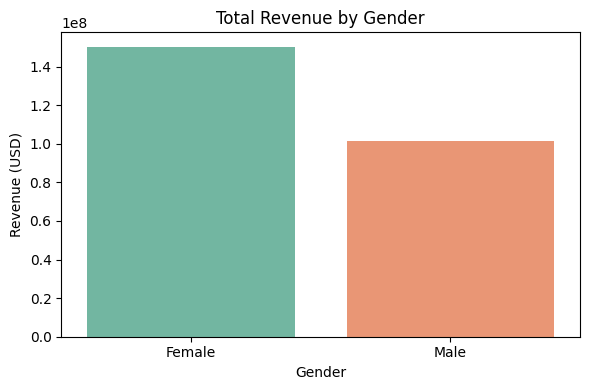

In [ ]:
df['total_amount'] = df['quantity'] * df['price']

query1 = '''
SELECT gender,
       ROUND(SUM(total_amount), 2) AS total_revenue
FROM df
GROUP BY gender
'''
gender_revenue = psql.sqldf(query1, locals())
plt.figure(figsize=(6, 4))
sns.barplot(x='gender', y='total_revenue', data=gender_revenue, palette='Set2')
plt.title("Total Revenue by Gender")
plt.ylabel("Revenue (USD)")
plt.xlabel("Gender")
plt.tight_layout()
plt.show()

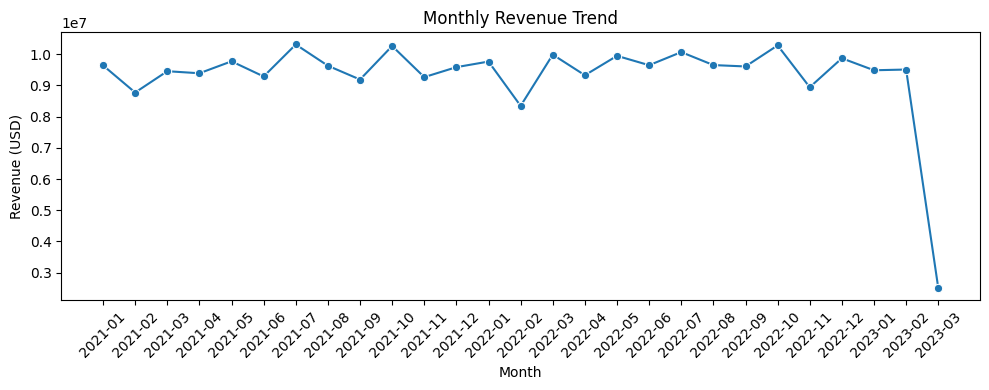

In [ ]:
query2 = '''
SELECT month,
       ROUND(SUM(total_amount), 2) AS total_revenue
FROM df
GROUP BY month
ORDER BY month
'''
monthly_sales = psql.sqldf(query2, locals())
plt.figure(figsize=(10, 4))
sns.lineplot(x='month', y='total_revenue', data=monthly_sales, marker='o')
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue (USD)")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
query3 = '''
SELECT payment_method,
       COUNT(*) AS usage_count
FROM df
GROUP BY payment_method
ORDER BY usage_count DESC;
'''
print("Most Popular Payment Methods:")
print(psql.sqldf(query3, locals()))

Most Popular Payment Methods:
  payment_method  usage_count
0           Cash        44447
1    Credit Card        34931
2     Debit Card        20079


/tmp/ipython-input-1311380097.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='usage_count', y='payment_method', data=payment_usage, palette='coolwarm')


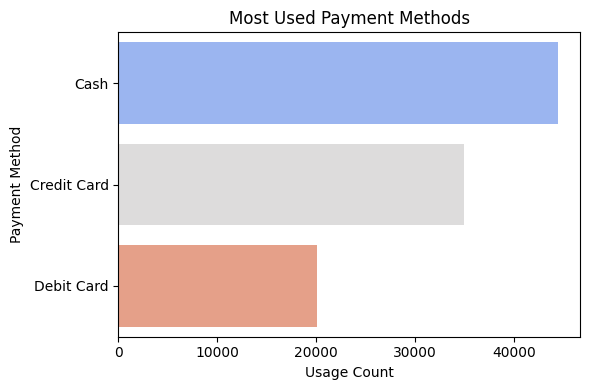

In [ ]:
query3 = '''
SELECT payment_method,
       COUNT(*) AS usage_count
FROM df
GROUP BY payment_method
ORDER BY usage_count DESC;
'''
payment_usage = psql.sqldf(query3, locals())
plt.figure(figsize=(6, 4))
sns.barplot(x='usage_count', y='payment_method', data=payment_usage, palette='coolwarm')
plt.title("Most Used Payment Methods")
plt.xlabel("Usage Count")
plt.ylabel("Payment Method")
plt.tight_layout()
plt.show()

/tmp/ipython-input-3306966756.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mall_revenue', y='shopping_mall', data=top_malls, palette='viridis')


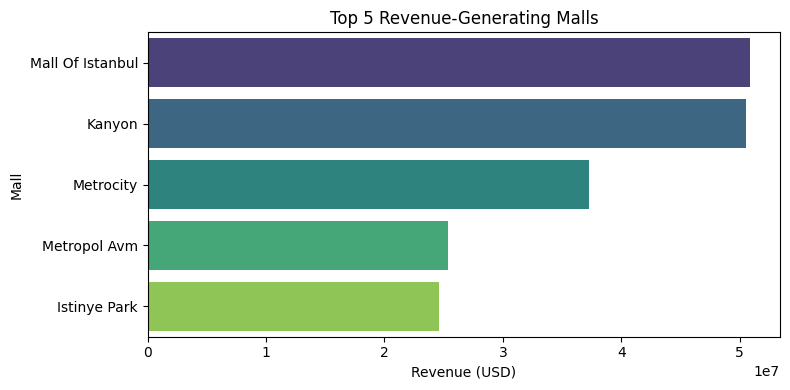

In [ ]:
query4 = '''
SELECT shopping_mall,
       ROUND(SUM(total_amount), 2) AS mall_revenue
FROM df
GROUP BY shopping_mall
ORDER BY mall_revenue DESC
LIMIT 5
'''
top_malls = psql.sqldf(query4, locals())
plt.figure(figsize=(8, 4))
sns.barplot(x='mall_revenue', y='shopping_mall', data=top_malls, palette='viridis')
plt.title("Top 5 Revenue-Generating Malls")
plt.xlabel("Revenue (USD)")
plt.ylabel("Mall")
plt.tight_layout()
plt.show()

/tmp/ipython-input-3473427649.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_mall_spending = df.groupby(['age_group', 'shopping_mall'])['total_amount'].mean().reset_index()


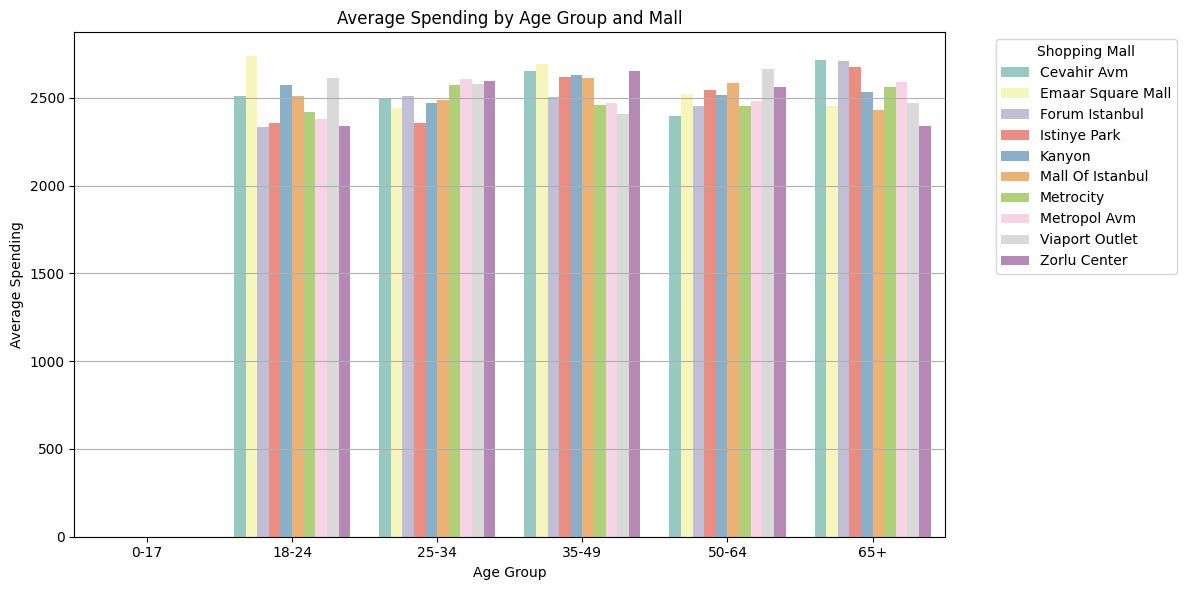

In [ ]:
age_mall_spending = df.groupby(['age_group', 'shopping_mall'])['total_amount'].mean().reset_index()

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=age_mall_spending, x='age_group', y='total_amount', hue='shopping_mall', palette='Set3')

plt.title('Average Spending by Age Group and Mall')
plt.xlabel('Age Group')
plt.ylabel('Average Spending')
plt.legend(title='Shopping Mall', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# Create age groups
bins = [0, 18, 25, 35, 50, 65, float('inf')]
labels = ['0-17', '18-24', '25-34', '35-49', '50-64', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)
display(df.head())

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,invoice_time,hour,month,total_amount,age_group
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-08-05,Kanyon,00:00:00,0,2022-08,7502.00,25-34
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,00:00:00,0,2021-12,5401.53,18-24
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-11-09,Metrocity,00:00:00,0,2021-11,300.08,18-24
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol Avm,00:00:00,0,2021-05,15004.25,65+
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon,00:00:00,0,2021-10,242.40,50-64


In [ ]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='age_group', y='total_amount', ci=None)
plt.title("Average Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Total Amount")
plt.tight_layout()
plt.show()

# - Target 26-35 and 36-50 age groups with personalized promotions.
